### Loss YOLOv11 Plots

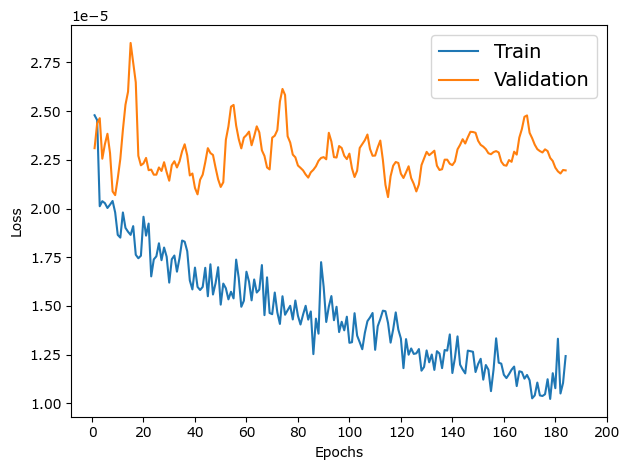

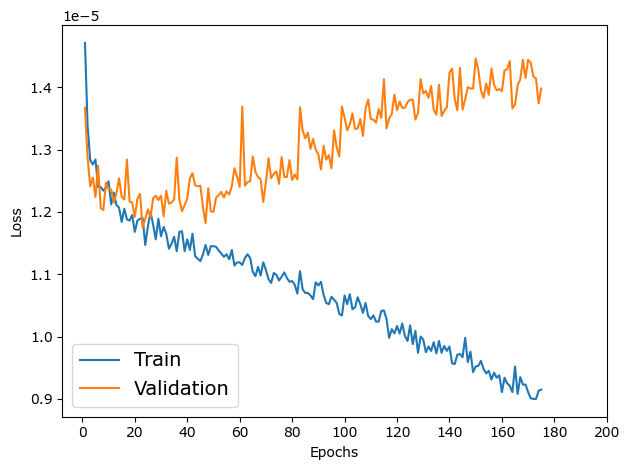

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def graph_plot(file_path, output_path, id):
    epochs = []
    train_cl = []
    val_cl = []
    epochs_i = []
    train_cl_i = []
    val_cl_i = []

    with open(file_path, 'r') as file:
        next(file)
        for line in file:
            # Divide the line in elments useing comas as dividers
            elements = line.strip().split(',')

            # Add each element to the corresponding list
            epochs.append(int(elements[0]))
            div_train = float(elements[2])
            div_val = float(elements[9])
            train_cl.append(div_train/1000)
            val_cl.append(div_val/1000)

    for i in range(0, len(epochs)):
        if i > 19:
            epochs_i.append(epochs[i])
            train_cl_i.append(train_cl[i])
            val_cl_i.append(val_cl[i])

    plt.plot(epochs, train_cl, label='Train')
    plt.plot(epochs, val_cl, label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(fontsize=14)

    custom_x_ticks = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
    plt.xticks(custom_x_ticks)
    
    plt.rcParams['font.family'] = 'Verdana'
    plt.tight_layout()
    plt.savefig(output_path + 'cls_loss' + id + '_Final.png', transparent=True, dpi=600)
    plt.show() 

#Change based on the path of the user that is running the code
userpath = 'C:/Users/camiz/'

output_path = userpath + 'Breast_Cancer_Investigation/DetectionModels/lossGraphs/'
input_path =  userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/'
input_path_1 = '.pt/test/train/results.csv'
modeln = 'yolo11n'

#INbreast
dataset = 'INbreast'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
graph_plot(n_input_path, output_path, 'nanoIN')

#CBIS
dataset = 'CBIS-DDSM'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
graph_plot(n_input_path, output_path, 'nanoCBIS')

### Performance Metrics (memory and time related) YOLOv11 Averages

In [ ]:
import csv
import numpy as np

def calculate_averages(file_route):
    times = []
    memories = []

    # Read CSV file
    with open(file_route, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            if row['phase'] == 'training':
                try:
                    time = float(row['time_seconds'])
                    memory = float(row['memory_mb'])
                    times.append(time)
                    memories.append(memory)
                except ValueError:
                    pass  # In case there are any missing values or not convertible

    # Calculate averages
    promedio_time = sum(times) / len(times) if times else 0
    promedio_memory = sum(memories) / len(memories) if memories else 0

    # Calculate standard desviations
    std_time = np.std(times) if len(times) > 1 else 0
    std_memory = np.std(memories) if len(memories) > 1 else 0

    # Print results
    print(f"MODEL: {model}")
    print(f"Average time in seconds (training): {promedio_time:.2f} ({std_time:.2f}) s")
    print(f"Average memory in MB (training): {promedio_memory:.2f} ({std_memory:.2f}) MB \n")

#Change based on the path of the user that is running the code
userpath = 'C:/Users/camiz/'

models = ['n', 's', 'm']

#INbreast
print("INbreast \n")
for model in models:
    file_route_IN = userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/INbreast/yolo11' + model + '.pt/performance_metrics_INbreast_final.csv'
    calculate_averages(file_route_IN)

#CBIS-DDSM
print("CBIS-DDSM \n")
for model in models:
    file_route_CBIS = userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/CBIS-DDSM/yolo11' + model + '.pt/performance_metrics_CBIS-DDSM_final.csv'
    calculate_averages(file_route_CBIS)

INbreast 

MODEL: n
Average time in seconds (training): 275.28 (19.37) s
Average memory in MB (training): 5010.24 (17.01) MB 

MODEL: s
Average time in seconds (training): 346.14 (45.37) s
Average memory in MB (training): 9279.78 (44.03) MB 

MODEL: m
Average time in seconds (training): 682.93 (95.15) s
Average memory in MB (training): 17737.10 (7.13) MB 

CBIS-DDSM 

MODEL: n
Average time in seconds (training): 2177.08 (225.22) s
Average memory in MB (training): 4984.77 (9.54) MB 

MODEL: s
Average time in seconds (training): 2793.96 (444.17) s
Average memory in MB (training): 9157.77 (23.42) MB 

MODEL: m
Average time in seconds (training): 5405.33 (565.79) s
Average memory in MB (training): 17753.40 (42.82) MB 

